# Image Embeddings with Voyage AI

Multimodal semantic search using `voyage-multimodal-3`. Each image (or image+caption pair) is embedded into a 1024-dim vector, enabling:

- **Text → image retrieval** — find the right image from a plain-text query
- **Image → image similarity** — pairwise similarity matrix across a corpus
- **Mixed content** — embed image + caption together for richer representations

Sample images are public-domain photos from Wikimedia Commons.

In [ ]:
# %pip install voyageai pillow requests python-dotenv

In [1]:
import os, io
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv
import voyageai

load_dotenv()

VOYAGEAI_API_KEY = os.getenv("VOYAGEAI_API_KEY")
assert VOYAGEAI_API_KEY, "Set VOYAGEAI_API_KEY in your .env file"

vo = voyageai.Client(api_key=VOYAGEAI_API_KEY)
print("Client ready")

Client ready


## 1. Download Sample Images

Five public-domain images from Wikimedia Commons covering diverse subjects.

In [2]:
SOURCES = {
    "loremflickr": "https://loremflickr.com/320/240/cat",
    "picsum":      "https://picsum.photos/id/573/320/240",
}

reachable = {}
for name, url in SOURCES.items():
    try:
        r = requests.get(url, timeout=10, allow_redirects=True)
        ok = r.status_code == 200 and len(r.content) > 1000
        reachable[name] = ok
        print(f"  {name:15} HTTP {r.status_code}  {len(r.content):>7} bytes  {'OK' if ok else 'BAD'}")
    except Exception as e:
        reachable[name] = False
        print(f"  {name:15} FAILED: {e}")

PRIMARY = "loremflickr" if reachable.get("loremflickr") else "picsum"
print(f"\nUsing source: {PRIMARY}")

  loremflickr     HTTP 200    10893 bytes  OK
  picsum          HTTP 200    19818 bytes  OK

Using source: loremflickr


In [3]:
ALL_URLS = {
    "loremflickr": {
        "cat":          "https://loremflickr.com/320/240/cat",
        "dog":          "https://loremflickr.com/320/240/dog",
        "eiffel_tower": "https://loremflickr.com/320/240/eiffeltower",
        "pizza":        "https://loremflickr.com/320/240/pizza",
        "sunflower":    "https://loremflickr.com/320/240/sunflower",
    },
    "picsum": {
        "cat":          "https://picsum.photos/id/573/320/240",
        "dog":          "https://picsum.photos/id/1062/320/240",
        "eiffel_tower": "https://picsum.photos/id/318/320/240",
        "pizza":        "https://picsum.photos/id/292/320/240",
        "sunflower":    "https://picsum.photos/id/82/320/240",
    },
}

def download_image(name):
    for source in [PRIMARY] + [s for s in ALL_URLS if s != PRIMARY]:
        url = ALL_URLS[source][name]
        try:
            resp = requests.get(url, timeout=15, allow_redirects=True)
            print(f"  [{source}] {name}: HTTP {resp.status_code}  {len(resp.content)} bytes")
            if resp.status_code == 200:
                return Image.open(io.BytesIO(resp.content)).convert("RGB")
        except Exception as e:
            print(f"  [{source}] {name}: ERROR {e}")
    raise RuntimeError(f"All sources failed for '{name}'")

images = {name: download_image(name) for name in ALL_URLS["loremflickr"]}
labels = list(images.keys())
print(f"\nDownloaded {len(images)} images")

  [loremflickr] cat: HTTP 200  20207 bytes
  [loremflickr] dog: HTTP 200  16327 bytes
  [loremflickr] eiffel_tower: HTTP 200  7508 bytes
  [loremflickr] pizza: HTTP 200  25481 bytes
  [loremflickr] sunflower: HTTP 200  17085 bytes

Downloaded 5 images


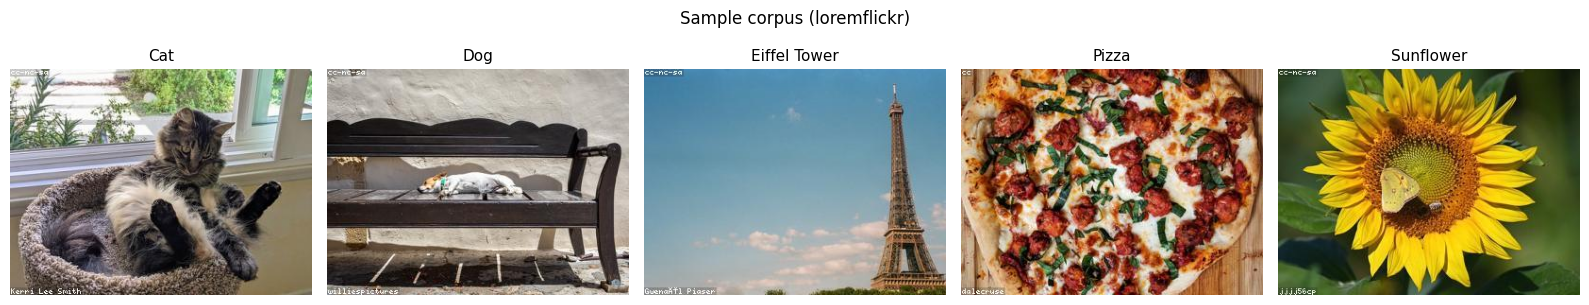

In [4]:
fig, axes = plt.subplots(1, len(images), figsize=(16, 3))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name.replace("_", " ").title(), fontsize=11)
    ax.axis("off")
plt.suptitle(f"Sample corpus ({PRIMARY})", y=1.02)
plt.tight_layout()
plt.show()

## 2. Embed Images

`vo.multimodal_embed()` accepts a list of *inputs*, where each input is itself a list of content items.
A content item can be a `str` (text), a `PIL.Image.Image`, or a `Video`.
Here each document is a single image.

```
inputs = [
    [image_1],   # document 0
    [image_2],   # document 1
    ...
]
```

In [5]:
doc_result = vo.multimodal_embed(
    inputs=[[images[k]] for k in labels],
    model="voyage-multimodal-3",
    input_type="document",
)

doc_embeddings = doc_result.embeddings

print(f"Documents embedded : {len(doc_embeddings)}")
print(f"Embedding dimension: {len(doc_embeddings[0])}")
print(f"Image pixels billed: {doc_result.image_pixels:,}")
print(f"Total tokens billed: {doc_result.total_tokens:,}")

Documents embedded : 5
Embedding dimension: 1024
Image pixels billed: 384,000
Total tokens billed: 685


## 3. Text → Image Retrieval

Embed text queries with `input_type="query"` (asymmetric retrieval), then rank images by cosine similarity.

In [6]:
def cosine_sim(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def retrieve(query_emb, corpus_embs, corpus_labels, top_k=3):
    scores = [(label, cosine_sim(query_emb, emb))
              for label, emb in zip(corpus_labels, corpus_embs)]
    return sorted(scores, key=lambda x: x[1], reverse=True)[:top_k]

In [7]:
text_queries = [
    "a fluffy domestic animal indoors",
    "Italian food with tomato sauce",
    "a famous iron landmark in Paris",
    "a bright yellow flower in full bloom",
    "a friendly dog outdoors",
]

query_result = vo.multimodal_embed(
    inputs=[[q] for q in text_queries],
    model="voyage-multimodal-3",
    input_type="query",
)

print("Text to Image Retrieval")
print("=" * 52)
for query, q_emb in zip(text_queries, query_result.embeddings):
    top = retrieve(q_emb, doc_embeddings, labels, top_k=3)
    print(f"\nQuery : {query!r}")
    for rank, (label, score) in enumerate(top, 1):
        bar = "#" * int(score * 40)
        print(f"  #{rank}  {label:<15} {score:.4f}  {bar}")

Text to Image Retrieval

Query : 'a fluffy domestic animal indoors'
  #1  cat             0.3958  ###############
  #2  dog             0.2599  ##########
  #3  sunflower       0.1666  ######

Query : 'Italian food with tomato sauce'
  #1  pizza           0.4078  ################
  #2  eiffel_tower    0.0773  ###
  #3  sunflower       0.0733  ##

Query : 'a famous iron landmark in Paris'
  #1  eiffel_tower    0.4338  #################
  #2  dog             0.0575  ##
  #3  pizza           0.0534  ##

Query : 'a bright yellow flower in full bloom'
  #1  sunflower       0.4198  ################
  #2  eiffel_tower    0.1736  ######
  #3  pizza           0.0897  ###

Query : 'a friendly dog outdoors'
  #1  dog             0.2808  ###########
  #2  sunflower       0.1726  ######
  #3  cat             0.1390  #####


## 4. Image → Image Similarity Matrix

Pairwise cosine similarity across all images. Diagonal is 1.0 (self-similarity).

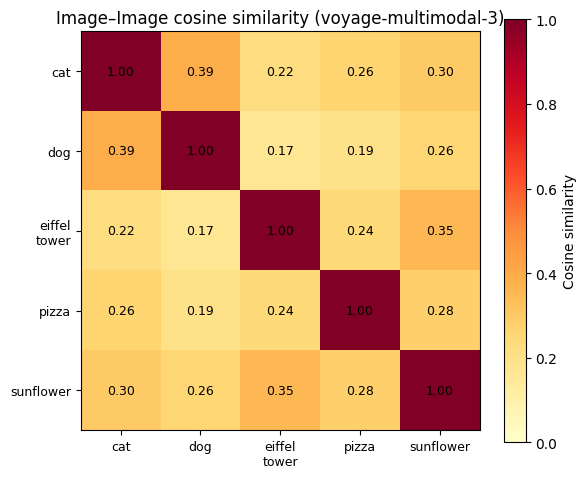

In [8]:
n = len(labels)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_sim(doc_embeddings[i], doc_embeddings[j])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
tick_labels = [l.replace("_", "\n") for l in labels]
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_yticklabels(tick_labels, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Cosine similarity")
ax.set_title("Image–Image cosine similarity (voyage-multimodal-3)")
plt.tight_layout()
plt.show()

## 5. Mixed Content — Image + Caption

Pass `[image, caption_text]` as a single input to fuse visual and textual signals into one embedding.
Compare retrieval quality vs. image-only embeddings.

In [9]:
CAPTIONS = {
    "cat":          "A cat photographed up close.",
    "dog":          "A dog photographed outdoors.",
    "eiffel_tower": "The Eiffel Tower in Paris.",
    "pizza":        "A pizza with tomato sauce and cheese.",
    "sunflower":    "A sunflower in full bloom.",
}

mixed_result = vo.multimodal_embed(
    inputs=[[images[k], CAPTIONS[k]] for k in labels],
    model="voyage-multimodal-3",
    input_type="document",
)
mixed_embeddings = mixed_result.embeddings

print(f"Mixed embeddings : {len(mixed_embeddings)} docs, dim={len(mixed_embeddings[0])}")
print(f"Image pixels     : {mixed_result.image_pixels:,}")
print(f"Text tokens      : {mixed_result.text_tokens:,}")

Mixed embeddings : 5 docs, dim=1024
Image pixels     : 384,000
Text tokens      : 34


In [10]:
print("Image-only vs Image+Caption retrieval")
print("=" * 56)
for query, q_emb in zip(text_queries, query_result.embeddings):
    top_img   = retrieve(q_emb, doc_embeddings,   labels, top_k=1)[0]
    top_mixed = retrieve(q_emb, mixed_embeddings, labels, top_k=1)[0]
    match = "same" if top_img[0] == top_mixed[0] else "different"
    print(f"\nQuery : {query!r}")
    print(f"  image only    -> {top_img[0]:<15}  score={top_img[1]:.4f}")
    print(f"  image+caption -> {top_mixed[0]:<15}  score={top_mixed[1]:.4f}  ({match})")

Image-only vs Image+Caption retrieval

Query : 'a fluffy domestic animal indoors'
  image only    -> cat              score=0.3958
  image+caption -> cat              score=0.4267  (same)

Query : 'Italian food with tomato sauce'
  image only    -> pizza            score=0.4078
  image+caption -> pizza            score=0.5352  (same)

Query : 'a famous iron landmark in Paris'
  image only    -> eiffel_tower     score=0.4338
  image+caption -> eiffel_tower     score=0.4219  (same)

Query : 'a bright yellow flower in full bloom'
  image only    -> sunflower        score=0.4198
  image+caption -> sunflower        score=0.4810  (same)

Query : 'a friendly dog outdoors'
  image only    -> dog              score=0.2808
  image+caption -> dog              score=0.4048  (same)


## 6. Use Your Own Image as a Query

Embed a local image and retrieve the most similar image from the corpus.

In [ ]:
# Replace with a path to any local image file
QUERY_IMAGE_PATH = "pdfs/your_image.jpg"

if os.path.exists(QUERY_IMAGE_PATH):
    query_img = Image.open(QUERY_IMAGE_PATH).convert("RGB")
    q_result = vo.multimodal_embed(
        inputs=[[query_img]],
        model="voyage-multimodal-3",
        input_type="query",
    )
    top = retrieve(q_result.embeddings[0], doc_embeddings, labels, top_k=3)
    print("Top matches for your image:")
    for rank, (label, score) in enumerate(top, 1):
        print(f"  #{rank}  {label:<15} score={score:.4f}")
else:
    print(f"File not found: {QUERY_IMAGE_PATH}")
    print("Update QUERY_IMAGE_PATH to point to a local image and re-run.")